In [21]:
# 는 오픈AI의 GPT API를 활용할 때 펑션 콜링을 사용했고, 08장에서는 랭체인에서 도구 호출하는 방법을 배웠습니다. 
# 랭그래프는 랭체인에 기반하므로 GPT와 같은 언어 모델 이 미리 정의한 도구를 사용할 수 있게 구현할 수 있습니다. 
# 이번 실습에서는 사용자가 주제를 제시하면 인터넷을 검색하여 최신 이슈를 기반으로 세부 주제를 선정하고, 그 주제를 검색해서 최종 기사를 작성하는 신문기자 챗봇을 만들겠습니다.

# 먼저 기사를 어떻게 작성할지 일의 순서를 설명합니다. 여기서 {about}에 주제만 입력하면 챗봇이 알아서 기사를 쓰도록 만들어 보겠습니다.

# 너는 신문기자이다.
# 최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

# - 최근 어떤 이슈가 있는지 검색하고 사람들이 제일 관심있어 할만한 주체를 선정하고 왜 선정했는지 말해줘.
# -그 내용으로 원고를 작성하기 위한 목차를 만들고 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트
# 로 정리해봐.
# - 검색할 리스트를 토대로 재검색해.
# - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고 있다면 추가로 검색해.
# - 검색된 결과에서 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.

# 더 이상 검색할 내용이 없다면 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
# 제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게
# 작성해야 한다.

# 현재 시간을 알려 주는 함수와 웹 검색을 하는 함수를 랭체인의 도구로 등록하고 랭그래프로 구현하겠습니다.

# pip uninstall -y langchain langchain-core langchain-community langgraph langgraph-checkpoint langsmith openai httpx
# pip install -U langgraph==0.2.74 langchain-core==0.3.35 langchain-openai==0.2.7 langgraph-checkpoint==2.0.16 langgraph-sdk==0.1.53 langsmith==0.3.8 openai==1.54.0 pydantic==2.7.4 httpx==0.27.0 tiktoken==0.12.0 python-dotenv pytz duckduckgo-search beautifulsoup4
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(model="gpt-4o", temperature=0.01)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_9dd8023e2f', 'finish_reason': 'stop', 'logprobs': None}, id='run-7ffe6231-c50c-457a-9436-ce4b6b441af0-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [22]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [23]:
# 랭그래프에서도 랭체인과 마찬가지로 도구를 정의하고 활용할 수 있습니다. 
# 08-3절과 10-4절에서 랭체인 도구를 다룰 때 사용한 시간을 알려 주는 get_current_time 함수와 웹 검색을 해주는 get_web_search 함수를 활용해 코드를 작성해 보겠습니다.
# get_web_search 함수를 도구로 등록해 보겠습니다. 10-4절의 streamlit_with_web_search.py 파일 코드를 참고하여 작성했습니다.

In [24]:
from langchain_core.tools import tool
from datetime import datetime
import pytz # pip install pytz
# from langchain_community.tools import DuckDuckGoSearchResults # pip install langchain-community==0.0.38
from duckduckgo_search import DDGS  # 이걸 직접 쓰는 게 안정적
#from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
# from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
# @tool # 이 함수를 랭체인과 랭그래프의 언어 모델에 연결하려면 @tool 데코레이터를 함수 위에 붙여서 tool로 등록해야 합니다. 이렇게 등록된 도구들은 tools에 리스트 형태로 담아 둡니다.
# def get_current_time(timezone: str, location: str) -> str:
#     """현재 시각을 반환하는 함수."""
#     try:
#         tz = pytz.timezone(timezone)
#         now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
#         result = f'{timezone} ({location}) 현재시각 {now}'
#         # print(result)
#         return result
#     except pytz.UnknownTimeZoneError:
#         return f"알 수 없는 타임존: {timezone}"
    
# @tool # 함수 get_web_search의 search_period 매개변수에 기본값으로 최근 1개월을 의미하는 'm'을 설정합니다.
# def get_web_search(query: str, search_period: str='m') -> str:
#     """
#     웹 검색을 수행하는 함수.

#     Args:
#         query (str): 검색어
#         search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

#     Returns:
#         str: 검색 결과
#     """
#     wrapper = DuckDuckGoSearchAPIWrapper(
#         # region="kr-kr", 검색 언어와 지역을 의미하는 region="kr-kr"과 뉴스 검색만 설정하는 source="news"는 주석으로 처리해서 자유롭게 검색할 수 있도록 합니다.
#         time=search_period
#     )

#     print('\n-------- WEB SEARCH --------')
#     print(query)
#     print(search_period)

#     search = DuckDuckGoSearchResults(
#         api_wrapper=wrapper,
#         # source="news", 검색 언어와 지역을 의미하는 region="kr-kr"과 뉴스 검색만 설정하는 source="news"는 주석으로 처리해서 자유롭게 검색할 수 있도록 합니다.
#         results_separator=';\n'
#     )

#     searched = search.invoke(query)
    
#     for i, result in enumerate(searched.split(';\n')):
#         print(f'{i+1}. {result}')
    
#     return searched

# # 도구 바인딩
# tools = [get_current_time, get_web_search]


from duckduckgo_search import DDGS  # 이걸 직접 쓰는 게 안정적

# -----------------------------
# 1. 시간 tool
# -----------------------------
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        return f"{timezone} ({location}) 현재시각 {now}"
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"


# -----------------------------
# 2. 웹 검색 tool (핵심 수정)
# -----------------------------
@tool
def get_web_search(query: str, search_period: str = "m") -> str:
    """
    웹 검색 함수 (DuckDuckGo 직접 사용 버전)
    """

    print("\n-------- WEB SEARCH --------")
    print("query:", query)
    print("period:", search_period)

    # DuckDuckGo 직접 호출 (langchain wrapper 제거)
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=5)

    output = []
    for i, r in enumerate(results):
        line = f"{i+1}. {r['title']} - {r['href']}"
        print(line)
        output.append(line)

    return "\n".join(output)


# -----------------------------
# 3. tools 리스트
# -----------------------------
tools = [get_current_time, get_web_search]

In [25]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-04-23 13:16:29'

In [26]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})
# tools[1].invoke("파이썬 m")



-------- WEB SEARCH --------
query: 파이썬
period: m
1. Welcome to Python.org - https://www.python.org/
2. Python - 나무위키 - https://namu.wiki/w/Python
3. Python 설치 방법 총정리 | Windows, Mac, Linux 초보자 가이드 - https://m.blog.naver.com/math717/223984322849
4. 파이썬 설치와 실행 방법 완벽 가이드 (Windows, VSCode, 주피터 ... - https://yinternational.co.kr/파이썬-설치와-실행-방법-완벽-가이드-windows-vscode-주피터-노/
5. 파이썬(Python): 시작하기 - 초보자를 위한 가이드 (+QnA) - https://nozaapsori.tistory.com/entry/Python-시작하기-초보자를-위한-가이드


C:\Users\MBC320\AppData\Local\Temp\ipykernel_7656\664344273.py:92: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


'1. Welcome to Python.org - https://www.python.org/\n2. Python - 나무위키 - https://namu.wiki/w/Python\n3. Python 설치 방법 총정리 | Windows, Mac, Linux 초보자 가이드 - https://m.blog.naver.com/math717/223984322849\n4. 파이썬 설치와 실행 방법 완벽 가이드 (Windows, VSCode, 주피터 ... - https://yinternational.co.kr/파이썬-설치와-실행-방법-완벽-가이드-windows-vscode-주피터-노/\n5. 파이썬(Python): 시작하기 - 초보자를 위한 가이드 (+QnA) - https://nozaapsori.tistory.com/entry/Python-시작하기-초보자를-위한-가이드'

In [27]:
# tools가 어떻게 저장되었는지 확인하기 위해서 다음과 같이 for 문을 사용해 하나씩 출력해 보겠습니다.
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x00000282F1A007C0>
get_web_search name='get_web_search' description='웹 검색 함수 (DuckDuckGo 직접 사용 버전)' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x00000282F1A00CC0>


In [28]:
# 이제 챗봇의 응답 메시지를 생성하는 generate 노드를 만들겠습니다.
# 그리고 model로 선언한 언어 모델에 .bind_tools로 붙인 model_with_tools로 도구를 사용합니다. 
# 이렇게 만든 generate 함수를 graph_builder에 "generate" 라는 이름의 노드로 붙입니다.

# ★ 언어 모델에 도구를 연결할 때.bind_tools를 사용하는 내용은 10-4절의 streamlit_with_web_search.py 파일을 작성할 때 다루었습니다.
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [29]:
# 랭그래프에서 도구를 편리하게 사용하기 위해 BasicToolNode 클래스를 만들겠습니다. 
# 지금 만들고 있는 랭그래프의 generate 노드에서 챗봇의 답변을 생성할 때 get_web_search 나 get_current_time과 같은 도구를 사용해야 한다면 따로 독립된 노드에서 실행하게 됩니다.
# BasicToolNode 클래스는 AIMessage에서 도구 요청이 있을 때 이롤 실행시키는 역할을 합니다.

import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    
    # 클래스의 초기화 메서드 ( __ init __ )에 있는 tools_by_name은 딕셔너리 형태로 도구의 이름과 해당 도구 자체를 저장합니다.
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    
    # __ call __ 메서드는 입력 메시지인 input을 딕셔너리 형태로 받습니다. 이때 input은 랭그래프에서 상태를 관리하는 state가 딕셔너리로 전달됩니다. state에는 messages가 포함되어 있습니다

        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    
        # 이 messages의 가장 최근 메시지에 tool_calls가 존재하면 도구를 사용해야 하므로 self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])를 for 문을 활용해 반복해서 실행합니다.
        # tool_call["args"]에는 그 도구를 사용할 때 필요한 인잣값이 들어갑니다. 실행 결과는 tool_result에 저장됩니다. 이 tool_result를 outputs 리스트에 추가합니다.
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)
# 이렇게 만든 BasicToolNode 클래스를 tools라는 이름의 노드로 graph_bui lder에 추가합니다.

In [30]:
# 12-1절과 12-2절에서 만들었던 랭그래프의 흐름은 갈림길 없이 진행되었습니다. 이번 실습에서는 흐름이 조금 더 다양해집니다. 
# 예를 들어 사용자가 질문하면 generate 노드에서 답변을 생성하고 그 후 바로 END 노드로 가서 작업을 끝낼 수도 있습니다. 
# 하지만 만약 인터넷 검색이나 시간 확인이 필요하다고 판단되면 tools 노드에서 그 기능을 수행한 후 결과를 바탕으로 다시 generate 노드에 돌아와 답변을 생성할 수도 있습니다. 
# 그리고 검색이나 시간 확인이 더 필요하다고 판단된다면 다시 tools 노드에서 작업을 반복할 수도 있습니다.

# 이번 실습에서는 AI 에이전트가 상황에 맞게 다음에 해야 할 일을 알아서 결정하도록 만들어 보겠습니다. 
# AI 에이전트가 랭그래프 내에서 스스로 다음 경로를 선택해야 할 때 라우터 router를 활용합니다. 
# 상황에 따라 방향을 결정하는 것을 라우팅 outing이라고하며 이때 조건에 따라 활성화되거나 비활성화되는 조건부 엣지conditional edge를 사용합니다.

# START에서 generate까지는 이전과 같이 순차로 진행하고 generate 노드에서 언어 모델이 판단한 결과에 따라 경로가 달라지도록 설정합니다. 
# 이를 위해 route_tools 함수를 만들고 state를 받아 messages 리스트에서 마지막 메시지를 확인합니다. 
# 만약 마지막 메시지에 tool_calls가 포함되어 있으면 tools 노드로 이동하여 필요한 도구를 실행하고, 없다면 END 노드로 이동하여 작업을 종료합니다. 
# tools 노드에서 작업을 마치면 다시 generate로 돌아옵니다.

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

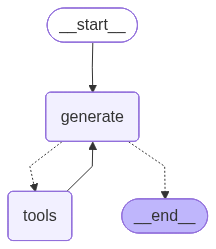

In [31]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [32]:
# 도구 테스트하고 기사 작성하기 
# 챗봇이 여러 도구 중에서 필요한 도구를 잘 찾아서 실행시키는지 테스트해 봅시다. 
# 이어서 웹 검색 후 기사 작성 기능을 구현해 봅시다. 
# 이때 '인터넷 검색해서 자료를 모으고 그걸로 기사써줘'라고 지시할 수도 있지만 주제를 명확히 제시하는 것이 좋습니다. 
# 어떤 내용을 작성해야 할지 순서대로 명시해야 언어 모델이 원하는 결과물을 만들어 낼 가능성이 커집니다. 
# 언어 모델은 단순히 가이드에 따라 문장을 생성하지만, 주제와 순서를 명확히 제시하면 생성해야 할 다음 문장들을 목적에 부합하게 작성할 수 있으니까요.

# messages에 HumanMessage로 '지금 서울 몇 시야?'라는 질문을 넣어 graph.stream으로 실행합니다. 
# 스트림 출력을 위해 graph.invoke가 아닌 .stream으로 설정하고 stream_mode는 'messages'로 설정합니다. 
# 결과가 AIMessageChunk로 나오자마자 for 문을 통해 즉각 출력됩니다. 
# AIMessageChunk는 조각난 상태로 조금씩 넘어오므로 gathered라는 변수에 조각들을 계속 붙여 나가도록 했습니다. 이렇게 완성한 최종 결과 gathered를 출력합니다.

from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울의 시간은 2026년 4월 23일 오후 1시 16분입니다.

AIMessageChunk(content='현재 서울의 시간은 2026년 4월 23일 오후 1시 16분입니다.', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_3xIZUETPe2KhnhrOBD3opRX9', 'function': {'arguments': '{"timezone":"Asia/Seoul","location":"서울"}', 'name': 'get_current_time'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-2024-08-06gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e045ad6cfdfp_d59908c1a9'}, id='run-6a4c5984-0016-48d4-81aa-619a6f47c5a0', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_3xIZUETPe2KhnhrOBD3opRX9', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_3xIZUETPe2KhnhrOBD3opRX9', 'index': 0, 'type': 'tool_call_chunk'}])

In [33]:
# 앞에서는 inputs에 HumanMessage를 사용했지만 이번에는 언어 모델에게 역할을 지시하기 위해 SystemMessage를 사용합니다. 
# 그리고 f-string에 기사 주제를 사용하여 {about}을 받아 오는 형태로 프롬프트를 입력합니다. 
# 여기에서는 '서울 월드컵 경기장 잔디 문제'라는 주제를 설정했습니다.
# 버전 최신화 문제로 아래 코드로 변환 함

# from langchain_core.messages import AIMessageChunk, SystemMessage

# about = "서울월드컵 경기장 잔디 문제"

# inputs = [SystemMessage(content=f"""
# 너는 신문기자이다. 
# 최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

# - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
# - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
# - 검색할 리스트를 토대로 재검색을 한다. 
# - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
# - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

# 더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
# 제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
# """)]

# for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
#     if isinstance(msg, AIMessageChunk):
#         print(msg.content, end='')


from langchain_core.messages import AIMessageChunk, SystemMessage
from langchain_core.messages import HumanMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [
    SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 작성한다.

- 최근 이슈 조사
- 핵심 주제 선정 및 이유
- 목차 구성
- 추가 검색 리스트 생성
- 부족하면 재검색
- 최종적으로 조선일보 스타일 기사 작성

형식:
제목 / 부제 / 리드문 / 본문
본문은 깊이 있게 작성
"""),
    HumanMessage(content="기사 작성 시작해")
]


# 스트리밍
for msg, metadata in graph.stream(
    {"messages": inputs},
    stream_mode="messages"
):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end="")


-------- WEB SEARCH --------
query: 서울월드컵 경기장 잔디 문제
period: m


C:\Users\MBC320\AppData\Local\Temp\ipykernel_7656\664344273.py:92: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. '논두렁 잔디' 오명 씻을까…서울월드컵경기장 복구 70% 완료 - 뉴스1 - https://www.news1.kr/local/seoul/5724597
2. '잔디 논란' 코리아컵에도 불똥…서울월드컵경기장 긴급 복구 작업 - https://www.joongang.co.kr/article/25318931
3. 린가드도 폭발한 '얼음 잔디', 결국 손본다...서울월드컵경기장 ... - https://www.chosun.com/sports/football/2025/03/07/KVVTAFVSLCWLEELOM2G3NDCNBA/
4. 서울월드컵 ‘논두렁 잔디’ 좀 나아질까... 시·공단 긴급 복구 - https://www.seoul.co.kr/news/society/2025/03/07/20250307500061
5. '논두렁 잔디' 오명 씻을까…서울월드컵경기장 복구 70% 완료 - 다음 - https://v.daum.net/v/20250320061011839
### 최근 이슈 조사

서울월드컵 경기장의 잔디 문제는 최근 여러 매체에서 다루고 있는 주요 이슈입니다. 경기장의 잔디 상태가 좋지 않아 경기 진행에 차질을 빚고 있으며, 이에 대한 복구 작업이 진행 중입니다. 특히, '논두렁 잔디'라는 표현이 사용될 정도로 잔디 상태가 심각하다는 평가가 나오고 있습니다.

### 핵심 주제 선정 및 이유

**핵심 주제: 서울월드컵 경기장 잔디 문제의 원인과 해결 방안**

이 주제를 선정한 이유는 서울월드컵 경기장은 국내외 주요 축구 경기가 열리는 장소로, 잔디 상태는 경기의 질과 선수들의 안전에 직접적인 영향을 미칩니다. 따라서 잔디 문제의 원인과 이를 해결하기 위한 방안을 심층적으로 분석하는 것이 중요합니다.

### 목차 구성

1. 서론: 서울월드컵 경기장 잔디 문제의 배경
2. 본론
   - 잔디 문제의 원인 분석
   - 잔디 문제로 인한 영향
   - 현재 진행 중인 복구 작업
3. 결론: 향후 개선 방안 및 제언

### 추가 검색 리스트 생성

1. 서울월드